# Potenziale doppio pozzo e potenziale armonico: forma e distribuzione di Boltzmann

Notebook per generare le due figure della tesi:
1. Potenziale doppio pozzo $V_{\text{dw}}(x_1)$ e relativa densità di Boltzmann $p(x_1)$
2. Potenziale armonico $V_{\text{arm}}(x)$ e relativa densità di Boltzmann $p(x)$

Parametri coerenti con il Capitolo sul sistema fisico: $a = 0.1$ eV, $b = 1.0$, $\Delta V = a/b^2 = 0.1$ eV, minimi in $x_1 = \pm 1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- stile coerente con il tema della tesi ---
ACCENTO = (20/255, 70/255, 40/255)      # verde scuro, stesso RGB{20,70,40} del tema LaTeX
ACCENTO_FILL = (20/255, 70/255, 40/255, 0.25)
GRIGIO = (0.35, 0.35, 0.35)

mpl.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 0.9,
    'axes.edgecolor': GRIGIO,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi': 130,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
})

In [2]:
# --- parametri fisici (Sezione sul potenziale doppio pozzo) ---
a = 0.1      # eV
b = 1.0      # unità di x1
kB = 8.617333262e-5   # eV/K, costante di Boltzmann

T = 300.0    # K, temperatura di riferimento per le figure

def V_dw(x, a=a, b=b):
    return (a / b**4) * (x**2 - b)**2

def V_arm(x):
    return 0.5 * x**2

def boltzmann_density(V, x, T, kB=kB):
    """Densita' di Boltzmann normalizzata p(x) ~ exp(-V(x)/(kB T)) su una griglia 1D."""
    beta = 1.0 / (kB * T)
    unnorm = np.exp(-beta * (V(x) - V(x).min()))   # shift per stabilita' numerica
    Z = np.trapezoid(unnorm, x)
    return unnorm / Z

delta_V = a / b**2
print(f"Delta V = {delta_V:.3f} eV,  Delta V / (kB T) a T={T} K -> {delta_V/(kB*T):.2f}")

Delta V = 0.100 eV,  Delta V / (kB T) a T=300.0 K -> 3.87


## Figura 1 — Potenziale doppio pozzo

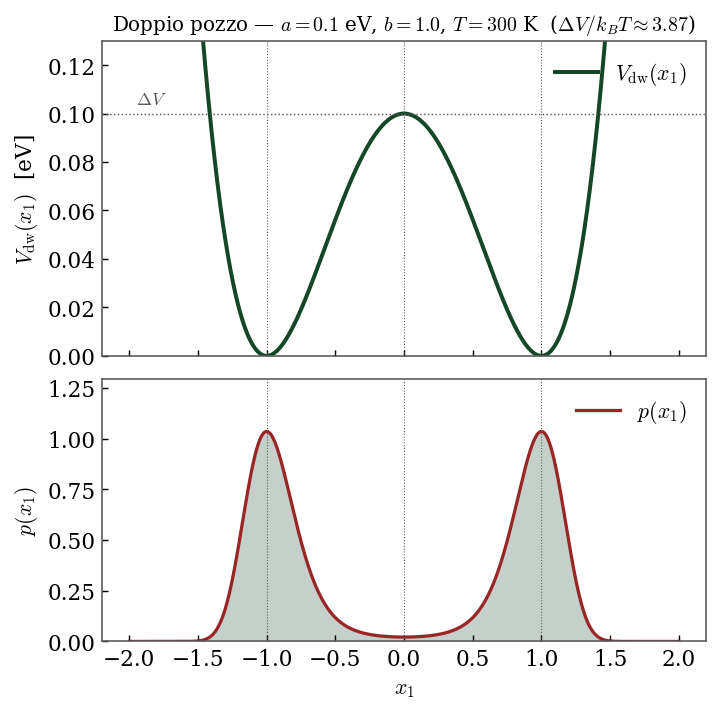

In [3]:
x = np.linspace(-2.0, 2.0, 2000)

V_vals = V_dw(x)
p_vals = boltzmann_density(V_dw, x, T)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6.0, 6.0), sharex=True,
    gridspec_kw={'height_ratios': [1.2, 1.0], 'hspace': 0.08}
)

# --- pannello superiore: potenziale ---
ax1.plot(x, V_vals, color=ACCENTO, lw=2.2, label=r'$V_{\mathrm{dw}}(x_1)$')
ax1.set_ylabel(r'$V_{\mathrm{dw}}(x_1)$  [eV]')
ax1.set_ylim(0, 0.13)

# barriera e minimi come guide visive
ax1.axhline(delta_V, color=GRIGIO, lw=0.8, ls=':')
ax1.text(-1.95, delta_V + 0.004, r'$\Delta V$', color=GRIGIO, fontsize=10)
ax1.axvline(0, color=GRIGIO, lw=0.6, ls=':')
ax1.axvline(-1, color=GRIGIO, lw=0.6, ls=':')
ax1.axvline(1, color=GRIGIO, lw=0.6, ls=':')
ax1.legend(loc='upper right', frameon=False)
ax1.set_title(rf'Doppio pozzo — $a={a}$ eV, $b={b}$, $T={T:.0f}$ K'
              rf'  ($\Delta V/k_BT \approx {delta_V/(kB*T):.2f}$)', fontsize=11)

# --- pannello inferiore: distribuzione di Boltzmann ---
ax2.fill_between(x, p_vals, color=ACCENTO_FILL, lw=0)
ax2.plot(x, p_vals, color=(0.6, 0.15, 0.15), lw=1.8, label=r'$p(x_1)$')
ax2.set_xlabel(r'$x_1$')
ax2.set_ylabel(r'$p(x_1)$')
ax2.set_ylim(0, p_vals.max() * 1.25)
ax2.axvline(0, color=GRIGIO, lw=0.6, ls=':')
ax2.axvline(-1, color=GRIGIO, lw=0.6, ls=':')
ax2.axvline(1, color=GRIGIO, lw=0.6, ls=':')
ax2.legend(loc='upper right', frameon=False)

fig.align_ylabels([ax1, ax2])
fig.savefig('/mnt/user-data/outputs/doppio_pozzo_boltzmann.pdf', bbox_inches='tight')
fig.savefig('/mnt/user-data/outputs/doppio_pozzo_boltzmann.png', bbox_inches='tight')
plt.show()

## Figura 2 — Potenziale armonico

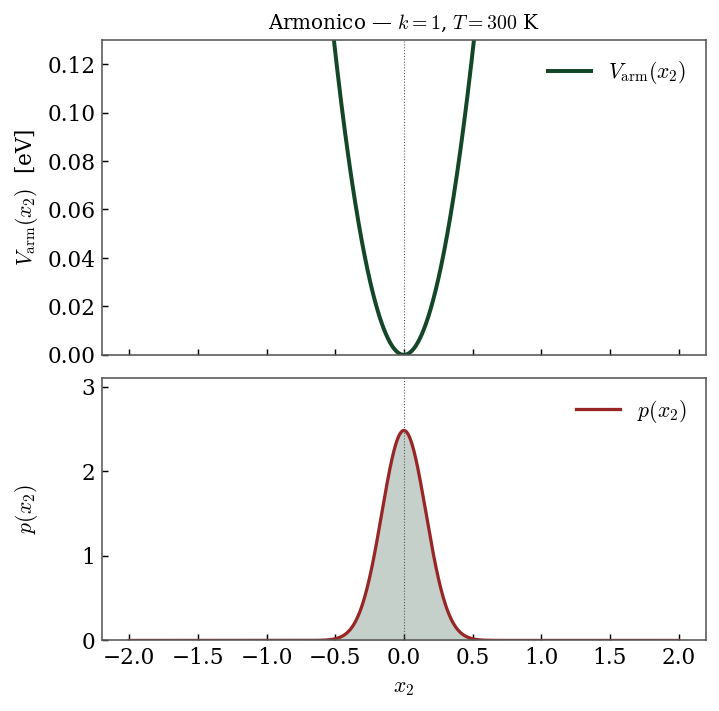

In [4]:
x2 = np.linspace(-2.0, 2.0, 2000)

Va_vals = V_arm(x2)
pa_vals = boltzmann_density(V_arm, x2, T)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6.0, 6.0), sharex=True,
    gridspec_kw={'height_ratios': [1.2, 1.0], 'hspace': 0.08}
)

# --- pannello superiore: potenziale ---
ax1.plot(x2, Va_vals, color=ACCENTO, lw=2.2, label=r'$V_{\mathrm{arm}}(x_2)$')
ax1.set_ylabel(r'$V_{\mathrm{arm}}(x_2)$  [eV]')
ax1.set_ylim(0, 0.13)
ax1.axvline(0, color=GRIGIO, lw=0.6, ls=':')
ax1.legend(loc='upper right', frameon=False)
ax1.set_title(rf'Armonico — $k=1$, $T={T:.0f}$ K', fontsize=11)

# --- pannello inferiore: distribuzione di Boltzmann ---
ax2.fill_between(x2, pa_vals, color=ACCENTO_FILL, lw=0)
ax2.plot(x2, pa_vals, color=(0.6, 0.15, 0.15), lw=1.8, label=r'$p(x_2)$')
ax2.set_xlabel(r'$x_2$')
ax2.set_ylabel(r'$p(x_2)$')
ax2.set_ylim(0, pa_vals.max() * 1.25)
ax2.axvline(0, color=GRIGIO, lw=0.6, ls=':')
ax2.legend(loc='upper right', frameon=False)

fig.align_ylabels([ax1, ax2])
fig.savefig('/mnt/user-data/outputs/armonico_boltzmann.pdf', bbox_inches='tight')
fig.savefig('/mnt/user-data/outputs/armonico_boltzmann.png', bbox_inches='tight')
plt.show()